In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [4]:
df = pd.read_csv("loan_data_set.csv")
df.head(5)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [6]:
#Brief overview of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [8]:
#Statistical figures of dataset
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [10]:
#Check for NaN / missing values
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

### Imputing Missing Values ###

In [33]:
#Return the list of numeric indices &* fill in NaN values
numeric_cols = ["ApplicantIncome","CoapplicantIncome"]

si = SimpleImputer(strategy = 'median')
df[numeric_cols] = si.fit_transform(df[numeric_cols])
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849.0,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583.0,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000.0,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583.0,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000.0,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900.0,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106.0,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072.0,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583.0,0.0,187.0,360.0,1.0,Urban,Y


### Remove Outliers ###

In [49]:
#pandas.api.types.is_numeric_dtype: Check whether the provided array or dtype is of a numeric dtype.
#Pandas uses bitwise operators

def remove_outliers(df, cols):
    for column in cols:
        if pd.api.types.is_numeric_dtype(df[column]):
            q1 = df[column].quantile(0.25)
            q3 = df[column].quantile(0.75)
            iqr = q3 - q1
            max_iqr = q3 + 1.5 * iqr
            min_iqr = q1 - 1.5 * iqr
            mask = (df[column] >= min_iqr) & (df[column] <= max_iqr)
            df = df[mask]
    return df
    
new_df = remove_outliers(df, numeric_cols)

### Standardization (Since it does not follow any proper distribution) ###

In [61]:
ss = StandardScaler()
for col in numeric_cols:
    new_df[col + "_ss"] = ss.fit_transform(new_df[[col]])
new_df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,ApplicantIncome_ss,CoapplicantIncome_ss
0,LP001002,Male,No,0,Graduate,No,5849.0,0.0,NaN,360.0,1.0,Urban,Y,0.902588,-0.933096
1,LP001003,Male,Yes,1,Graduate,No,4583.0,1508.0,128.0,360.0,1.0,Rural,N,0.238250,0.101980
2,LP001005,Male,Yes,0,Graduate,Yes,3000.0,0.0,66.0,360.0,1.0,Urban,Y,-0.592435,-0.933096
3,LP001006,Male,Yes,0,Not Graduate,No,2583.0,2358.0,120.0,360.0,1.0,Urban,Y,-0.811258,0.685412
4,LP001008,Male,No,0,Graduate,No,6000.0,0.0,141.0,360.0,1.0,Urban,Y,0.981826,-0.933096
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900.0,0.0,71.0,360.0,1.0,Rural,Y,-0.644911,-0.933096
610,LP002979,Male,Yes,3+,Graduate,No,4106.0,0.0,40.0,180.0,1.0,Rural,Y,-0.012058,-0.933096
611,LP002983,Male,Yes,1,Graduate,No,8072.0,240.0,253.0,360.0,1.0,Urban,Y,2.069115,-0.768362
612,LP002984,Male,Yes,2,Graduate,No,7583.0,0.0,187.0,360.0,1.0,Urban,Y,1.812511,-0.933096


C:\Users\Cresht\AppData\Local\Temp\ipykernel_4204\2878807578.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x = new_df["ApplicantIncome"], kde = True)
C:\Users\Cresht\AppData\Local\Temp\ipykernel_4204\2878807578.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x = new_df["ApplicantIncome

<Axes: ylabel='Density'>

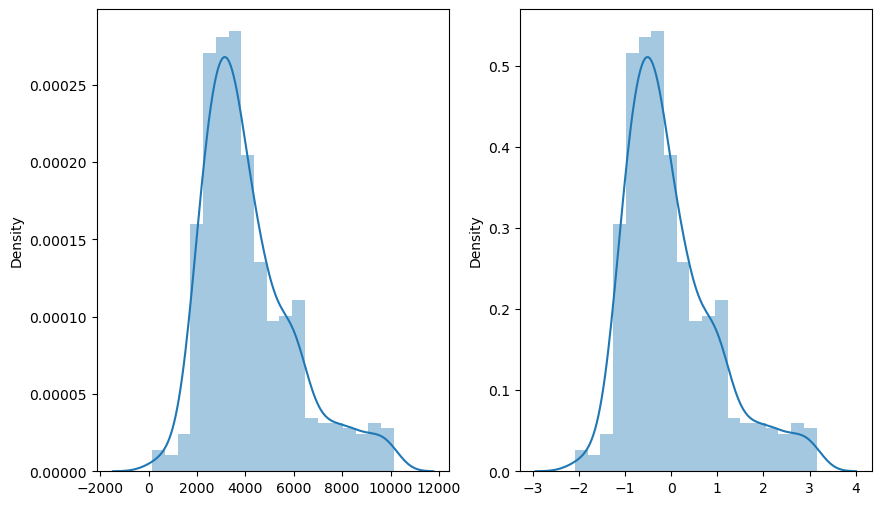

In [68]:
#Visualisation on featured scaling
plt.figure(figsize = (10, 6))
plt.subplot(1, 2, 1)
sns.distplot(x = new_df["ApplicantIncome"], kde = True)
plt.subplot(1, 2, 2)
sns.distplot(x = new_df["ApplicantIncome_ss"], kde = True)

C:\Users\Cresht\AppData\Local\Temp\ipykernel_4204\1403537042.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x = new_df["CoapplicantIncome"], kde = True)
C:\Users\Cresht\AppData\Local\Temp\ipykernel_4204\1403537042.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x = new_df["CoapplicantIn

<Axes: ylabel='Density'>

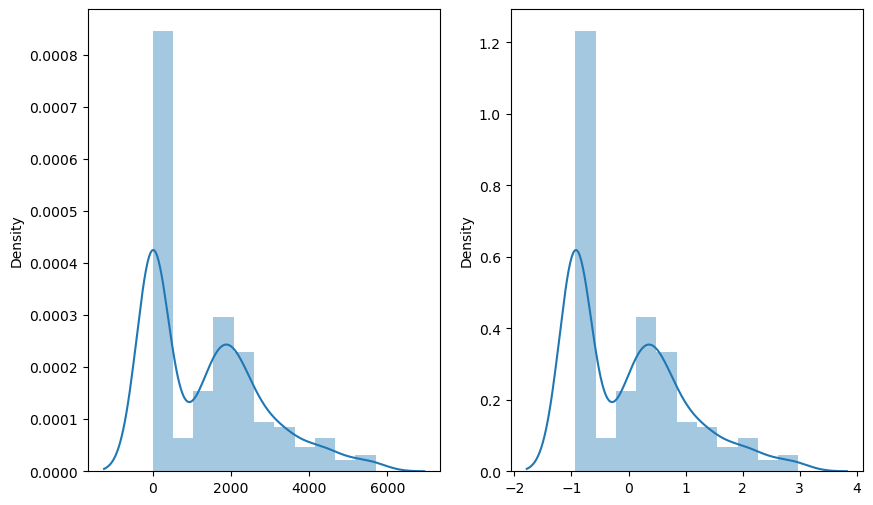

In [70]:
plt.figure(figsize = (10, 6))
plt.subplot(1, 2, 1)
sns.distplot(x = new_df["CoapplicantIncome"], kde = True)
plt.subplot(1, 2, 2)
sns.distplot(x = new_df["CoapplicantIncome_ss"], kde = True)

(array([  7.,  42., 141., 143.,  83.,  58.,  27.,  17.,  13.,  17.]),
 array([  150. ,  1148.9,  2147.8,  3146.7,  4145.6,  5144.5,  6143.4,
         7142.3,  8141.2,  9140.1, 10139. ]),
 <BarContainer object of 10 artists>)

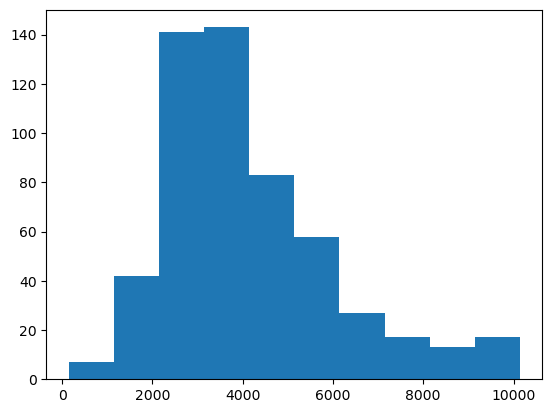

In [74]:
plt.hist(x = new_df["ApplicantIncome"])

### Changing Datatypes ###

In [87]:
#Remove NaN values
new_df["Dependents"].value_counts()
#Replacing values with first most frequently appeared ones [0], otherwise continue with the latter
new_df["Dependents"] = new_df["Dependents"].fillna(new_df["Dependents"].mode()[0])
#Replace invalid datatype (3+ → 3)
new_df["Dependents"] = new_df["Dependents"].replace("3+", "3")
#Change the datatype
new_df["Dependents"] = new_df["Dependents"].astype("int32")

In [89]:
new_df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,ApplicantIncome_ss,CoapplicantIncome_ss
0,LP001002,Male,No,0,Graduate,No,5849.0,0.0,NaN,360.0,1.0,Urban,Y,0.902588,-0.933096
1,LP001003,Male,Yes,1,Graduate,No,4583.0,1508.0,128.0,360.0,1.0,Rural,N,0.238250,0.101980
2,LP001005,Male,Yes,0,Graduate,Yes,3000.0,0.0,66.0,360.0,1.0,Urban,Y,-0.592435,-0.933096
3,LP001006,Male,Yes,0,Not Graduate,No,2583.0,2358.0,120.0,360.0,1.0,Urban,Y,-0.811258,0.685412
4,LP001008,Male,No,0,Graduate,No,6000.0,0.0,141.0,360.0,1.0,Urban,Y,0.981826,-0.933096
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900.0,0.0,71.0,360.0,1.0,Rural,Y,-0.644911,-0.933096
610,LP002979,Male,Yes,3,Graduate,No,4106.0,0.0,40.0,180.0,1.0,Rural,Y,-0.012058,-0.933096
611,LP002983,Male,Yes,1,Graduate,No,8072.0,240.0,253.0,360.0,1.0,Urban,Y,2.069115,-0.768362
612,LP002984,Male,Yes,2,Graduate,No,7583.0,0.0,187.0,360.0,1.0,Urban,Y,1.812511,-0.933096


### Notes ###

If there exists many columns having values like "3+", "N/A" or "None", we could be using dictionaries

improper_values = {"3+": 3, "N/A": None, "None": None}

df.replace(improper_values, inplace=True)